# Extract Specialist Data

Extracts specialist (Item / ItemWithBoost) assets from Anno 117 into CSV and JSON files. Output goes to `results/tables/`.

Run all cells from the project root.

## Load Assets

Setup game data for processing.

In [1]:
from assetextractor.extraction.utils import Config
from assetextractor.parsing.core.assets import AssetCache

config = Config.from_json("config.json")
assets = AssetCache.load(config)
templates = assets.templates

print(f"Total assets: {len(assets.elements)}")
print(f"Total texts: {len(assets.texts.elements)}")

Total assets: 30713
Total texts: 33147


## Extract Specialist Assets.

Extract the specialists from `Item` and `ItemWithBoost` and print the quantity of assets.

In [2]:
# Misc: This allow reloading .py modules into jupyter.
%load_ext autoreload
%autoreload 3

In [3]:
from assetextractor.conversion.statistics.specialist_extractor import SpecialistExtractor

extractor = SpecialistExtractor(assets)
# extractor_de = SpecialistExtractor(assets, language="german")
specialist_collection_data = extractor.extract_all()

specialists_data = specialist_collection_data.items
specialists_boost_data = specialist_collection_data.items_with_boost

print(f"Processed {len(specialists_data.keys())} specialists.")
print(f"Processed {len(specialists_boost_data.keys())} specialists with boost.")

Processed 352 specialists.
Processed 82 specialists with boost.


## Print Specialists and their details

Use `extractor.print_specialists()` to see everything, or `extractor.print_specialists(guid=71438)` (*"Gaius Julius Lupus, Castor of Fortunes"* as example) to inspect a specific one.


                  SPECIALIST: Maxima Cottius, Upholsterer of Atlas (GUID: 44149)                    



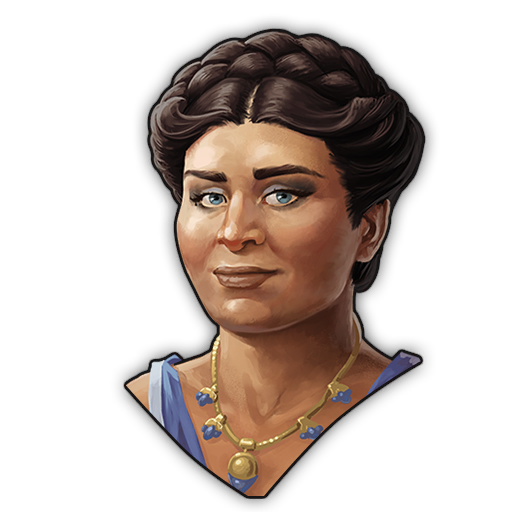

----------------------------------------------------------------------------------------------------
Allocation:    Villa
Rarity:        Epic
Niche:         Culture
Trade Price:   120000
Origin:        BaseRelease
     └── Buff #1: Specialist Productivity E LoungersChain Buff (GUID: 44160)
         ├── [Factory Upgrade Attributes]:
         │   └── [Productivity]: +35%       (Raw: 35.0)
     └── Target #1: Asset Pool Loungers Chain (GUID: 50599)
         ├── Target #1: Production Household Roman Loungers (GUID: 3198)
         │   ├── [Costs]: 0 Denarii, 2 Timber, 3 Tiles, 2 Concrete, 4 Marble, 3 Mosaics
         │   ├── [Maintenance]: 28 Denarii, 12 Patrician Workforce
         │   └── [Category Name]: Workshop
         ├── Target #2: Production Field Roman Sandarac Wood (GUID: 8579)
         │   ├── [Costs]: 0 Denarii, 2 Timber, 3 Tiles, 1 Concrete, 0 Marble, 0 Mosaics
         │   ├── [Maintenance]: 8 Denarii, 3 Libertus Workforce
         │   └── [Category Name]: Forest Camp
       

In [4]:
extractor.print_specialists(44149) # Maxima Cottius, Upholsterer of Atlas


                              SPECIALIST: Olive Reaper (GUID: 144866)                               



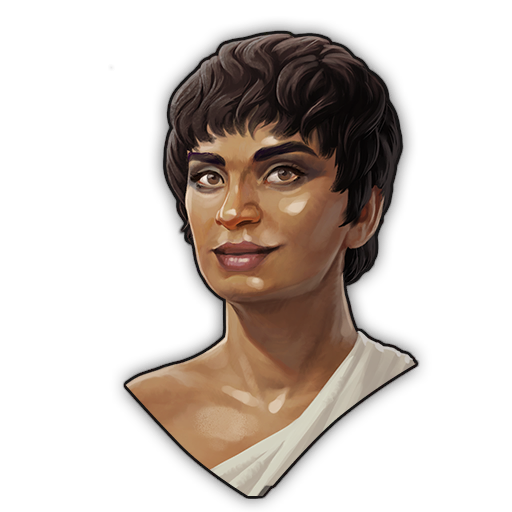

----------------------------------------------------------------------------------------------------
Allocation:    Villa
Rarity:        Common
Niche:         Agriculture
Trade Price:   5040
Origin:        DLC01
     └── Buff #1: Specialist Farming C Olives Buff (GUID: 144867)
         ├── [Factory Upgrade Attributes]:
         │   └── [Added Fertility]: Fertility Roman Olives (Raw: 50%)
     └── Target #1: Production Field Roman Olives (GUID: 2699)
         ├── [Costs]: 0 Denarii, 1 Timber, 3 Tiles, 0 Concrete, 0 Marble, 0 Mosaics
         ├── [Maintenance]: 6 Denarii, 4 Libertus Workforce
         └── [Category Name]: Plantation


In [5]:
extractor.print_specialists(144866) # Olive Reaper (From PoA DLC)


                            SPECIALIST: Elephant Handler (GUID: 44431)                              



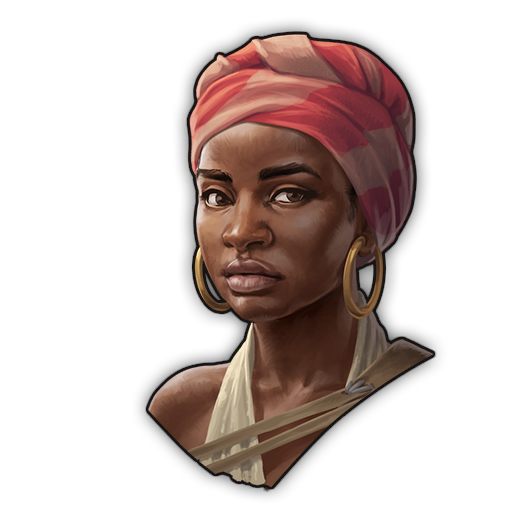

----------------------------------------------------------------------------------------------------
Allocation:    Villa
Rarity:        Rare
Niche:         Diplomacy
Trade Price:   15000
Origin:        BaseRelease
     └── Buff #1: Specialist Campaign Elephant Handler Buff (GUID: 44432)
         ├── [Factory Upgrade Attributes]:
         │   └── [Productivity]: +20%       (Raw: 20.0)
     └── Target #1: Asset Pool Production All Farms (GUID: 42602)
         ├── Target #1: Production Field Roman Wheat (GUID: 2693)
         │   ├── [Costs]: 0 Denarii, 3 Timber, 1 Tiles, 0 Concrete, 0 Marble, 0 Mosaics
         │   ├── [Maintenance]: 6 Denarii, 4 Libertus Workforce
         │   └── [Category Name]: Arable Farm
         ├── Target #2: Production Field Roman Celtic Wheat (GUID: 5972)
         │   ├── [Costs]: 0 Denarii, 3 Timber, 1 Tiles, 0 Concrete
         │   ├── [Maintenance]: 6 Denarii, 4 Wader Workforce
         │   └── [Category Name]: Arable Farm
         ├── Target #3: Production 

In [6]:
extractor.print_specialists(44431) # Elephant Handler


               SPECIALIST (WITH BOOST): Dorian, Philos of Philhellenes (GUID: 41350)                



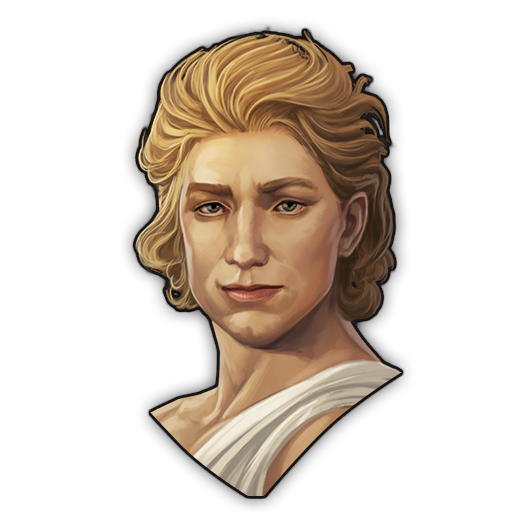

----------------------------------------------------------------------------------------------------
Allocation:    Villa
Rarity:        Unique
Niche:         Culture
Trade Price:   1000
Origin:        BaseRelease
     └── Buff #1: Specialist Rival 01 Dorian Buff (GUID: 40496)
         ├── [Residence Upgrade Attributes]:
         │   ├── [Health]:       +3         (Raw: 3.0)
         │   └── [Fire Safety]:  +1         (Raw: 1.0)
     └── Target #1: Residence Roman 03 Equites (GUID: 3142)
         ├── [Costs]: 0 Denarii, 1 Timber, 1 Tiles, 0 Concrete, 0 Marble, 0 Mosaics
         └── [Category Name]: Roman Residence


In [7]:
extractor.print_specialists(41350) # Specialist Rival 01 Dorian Buff -> This one has percentage attributes

## Export to JSON & Image Export

Using the `save_to_json` method from the extractor. You can pass a custom `web_base_path` to fit your webapp asset structure. If left empty, it will provide the original image game path within the asset extractor.

The `IconProcessor` is a static utility class designed for batch processing, resizing, and converting `.dds` game icons into web-ready `.webp` files.

The `IconProcessor.export_icons()` method allows for either a Flattened structure (optimized for simple galleries) or a Mirrored structure (mimicking the game's internal directory hierarchy).

This is done by using wand + magick within the IconProcessor.

In [8]:
from pathlib import Path

# Define base output folder
output_root = Path("results")

In [9]:
# =================================================================
# SCENARIO A: MIRRORED STRUCTURE (Mimics Game Folders)
# Use this for: Webapps that need the full "base/icon_content/..." tree.
# =================================================================
print(f" Scenario A: Mirrored ".center(80, "*"))
    
# 1. Export ALL physical files (Icons @ 128px)
# Recreates the game's directory hierarchy for everything.
extractor.export_all_assets(
    output_base=output_root / "icons",
    quality=75,
    flatten=False        # Mirror hierarchy for standard assets & portraits
)

# 2. Save JSON with URLs like: "base/icon_content/religion/icon_name.webp"
# extractor.save_to_json(
#     file_path=output_root / "tables/specialists_en.json",
#     web_base_path="assets/icons",  # No prefix (None) -> relative path from game tree root
#     flatten=False             # Matches the mirrored file export paths
# )

***************************** Scenario A: Mirrored *****************************
Exporting 434 specialist icons...
  [OK] -> icons\base\icon_content\items_specialist\roman_male\icon_3d_roman_male_75_0.webp
  [OK] -> icons\base\icon_content\items_specialist\celtic_female\icon_3d_celtic_female_026_0.webp
  [OK] -> icons\base\icon_content\items_specialist\celtic_male\icon_3d_celtic_male_014_0.webp
  [OK] -> icons\base\icon_content\items_specialist\celtic_male\icon_3d_celtic_male_005_0.webp
  [OK] -> icons\base\icon_content\items_specialist\roman_male\icon_3d_roman_male_006_0.webp
  [OK] -> icons\base\icon_content\items_specialist\nonbinary\icon_3d_celtic_nb_02_0.webp
  [OK] -> icons\base\icon_content\items_specialist\roman_male\icon_3d_roman_male_019_0.webp
  [OK] -> icons\base\icon_content\items_specialist\unique\icon_3d_unique_005_circaeus_of_aeaea_0.webp
  [OK] -> icons\base\icon_content\items_specialist\unique\icon_3d_campaign_elephant_0.webp
  [OK] -> icons\base\icon_content\items_sp